# Отчет по эмпирическому анализу алгоритмов сортировки строк
github - 
**ID успешных посылок в тестирующей системе CodeForces:**
* **A1m** (STRING MERGE SORT): 375907651
* **A1q** (STRING QUICK SORT): 375907887
* **A1r** (MSD RADIX SORT): 375908326
* **A1rq** (MSD RADIX + QUICK SORT): 375908499

*Примечание к реализации:*  для стандартного `QUICKSORT` и адаптированного `STRING QUICKSORT` был использован одинаковый способ выбора опорного элемента — выбор центрального элемента подмассива: `mid = left + (right - left) / 2`.

---

## 1. Сравнение со стандартными алгоритмами и теоретическая оценка (Random, Reversed, NearlySorted)

На случайных и почти отсортированных наборах данных классические алгоритмы (`Std_QuickSort`, `Std_MergeSort`) демонстрируют теоретическую асимптотику $\Omega(n \cdot \log n)$. Однако эта оценка учитывает только сравнение элементов целиком. При сортировке строк реальная сложность возрастает из-за необходимости посимвольного сравнения

**Поведение специализированных алгоритмов:**
* **Ternary String QuickSort:** Теоретическая сложность алгоритма составляет $O(N \log N + S)$, где $S$ — суммарная длина всех строк. На практике он стабильно опережает `Std_QuickSort`. Разделяя массив на три части (меньше, равно, больше), алгоритм группирует строки с одинаковыми префиксами и не тратит время на повторную проверку этих символов на глубине рекурсии.
* **MSD Radix Sort (без переключения):** Демонстрирует линейное поведение, так как его сложность $O(N \cdot W)$ (где $W$ — длина строки) не зависит от $\log N$. Алгоритм не сравнивает символы напрямую, а использует их как индексы, что делает его самым быстрым на полностью случайных данных.

---

## 2. Анализ LCP MergeSort (массив Prefixed)

Массив `Prefixed` (строки с длинным общим началом) наглядно показывает недостатки стандартных подходов. Графики для этого набора данных представлены в логарифмической шкале.

* **Стандартный MergeSort:** При каждом слиянии заново сравнивает одни и те же префиксы, совершая колоссальное количество операций (до $10^6$ посимвольных сравнений).
* **String MergeSort (LCP):** Адаптированный алгоритм кэширует длину наибольшего общего префикса. Его теоретическая сложность $O(N \log N + \sum LCP(R))$ подтверждается графиками: количество сравнений падает в десятки раз по сравнению со стандартной версией. Алгоритм просто пропускает уже проверенные участки строк, что дает огромный выигрыш по времени.

---

## 3. Эффективность гибридного алгоритма (MSD Hybrid)

В  MSD Radix Sort имеет огромные накладные расходы по памяти: на каждом шаге рекурсии создается массив-счетчик размером с мощность алфавита (в нашем случае 74 символа). Для малых подмассивов затраты на создание пустых корзин превышают полезную работу.

**Анализ гибридного подхода:**
Переключение `MSD_Hybrid` на `Ternary_QS` в тот момент, когда длина сортируемого подмассива становится меньше мощности алфавита ($< 74$), элегантно решает эту проблему. Как видно на графиках времени выполнения (нижняя коричневая кривая), гибридная версия отсекает накладные расходы на нижних уровнях дерева рекурсии. В результате этот алгоритм стабильно обгоняет как стандартные методы, так и чистый MSD Radix Sort, показывая наилучшие результаты среди всех протестированных сортировок.

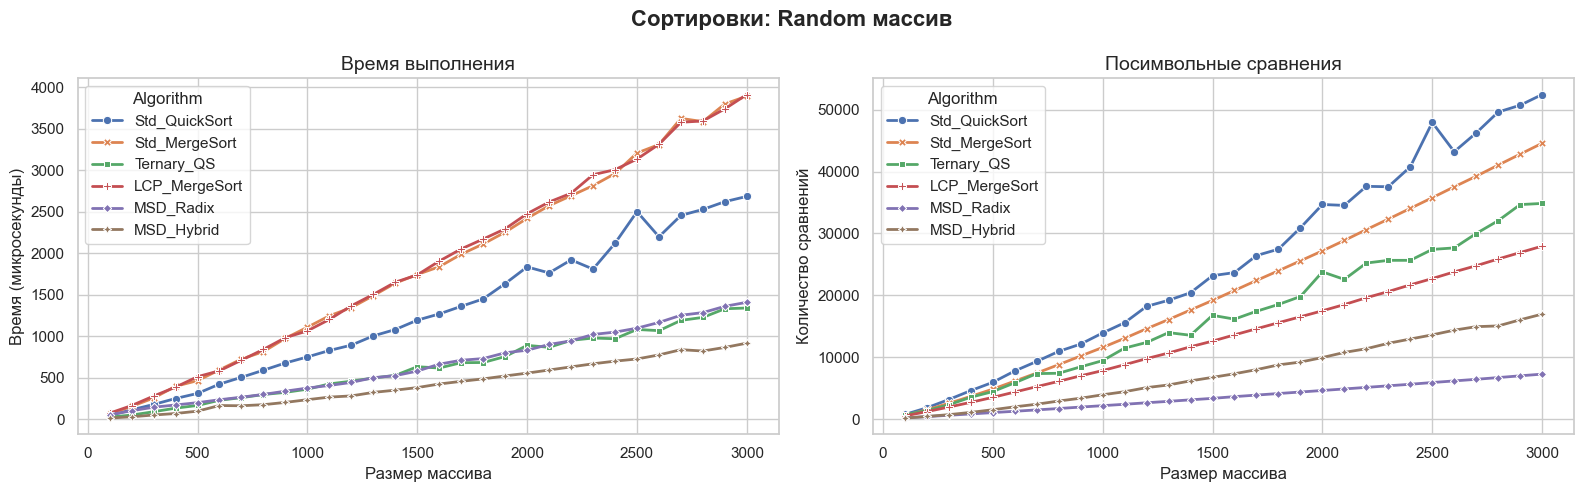

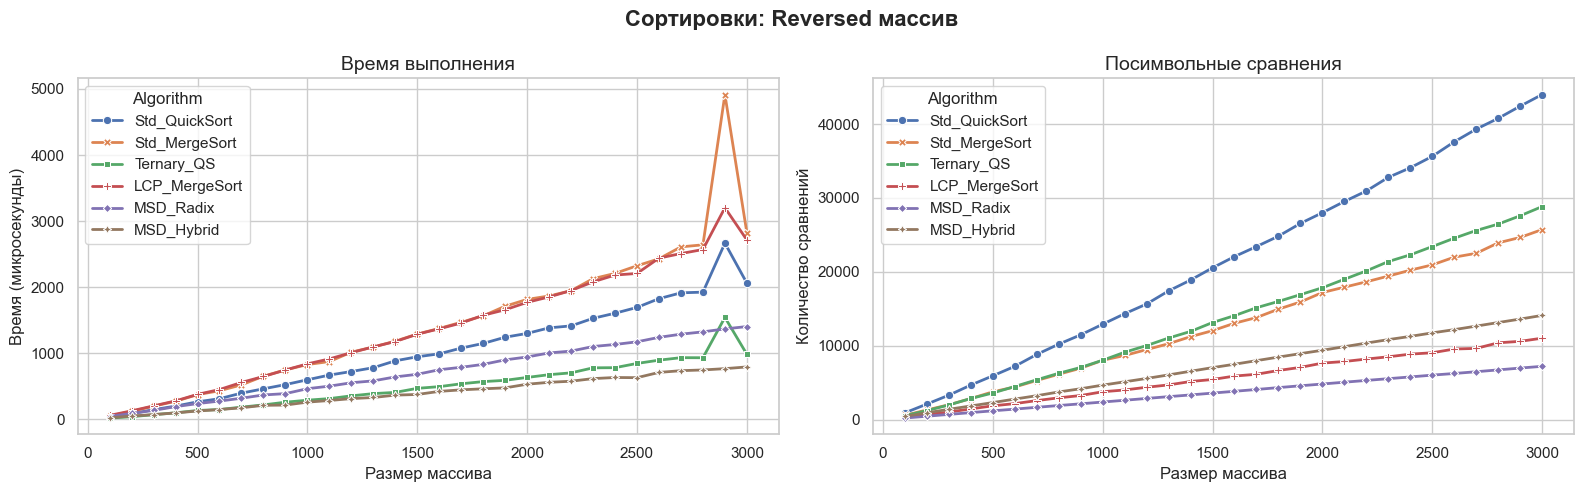

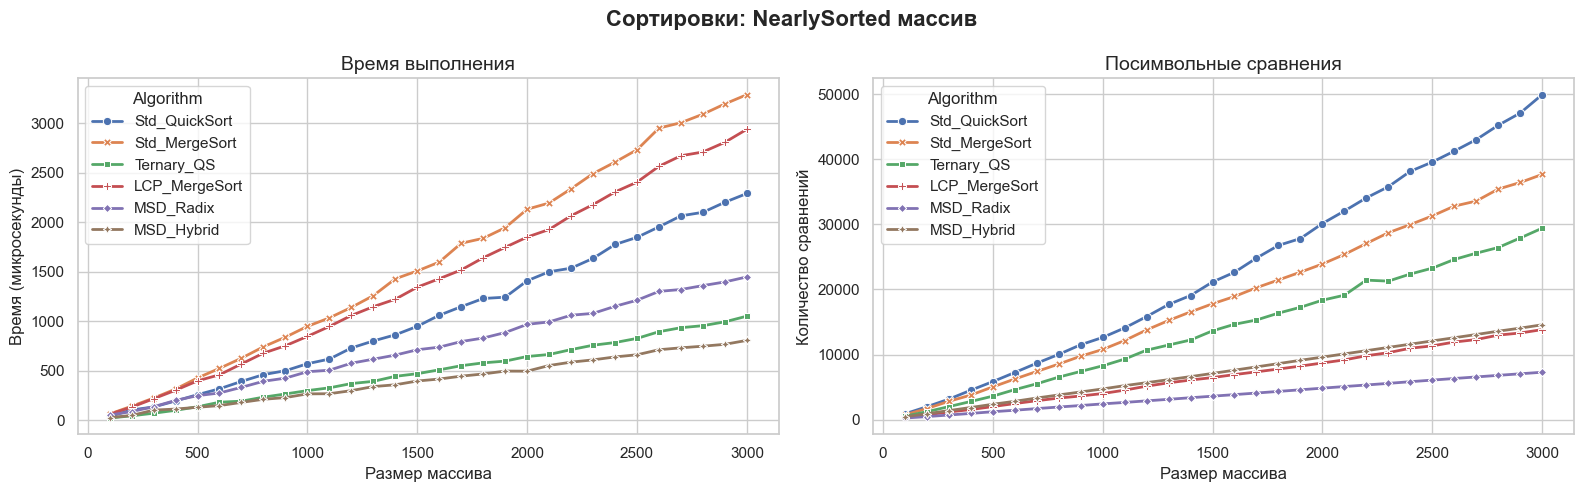

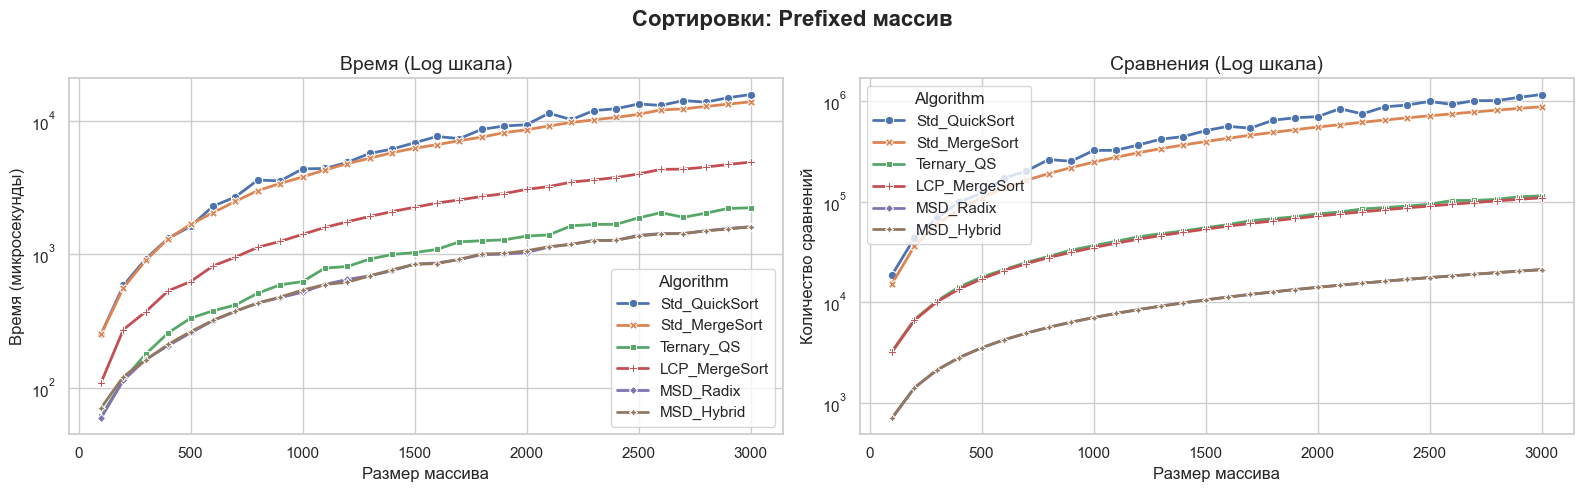

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

%matplotlib inline

csv_filename = "results.csv"

if not os.path.exists(csv_filename):
    print(f"Ошибка: Файл {csv_filename} не найден!")
else:
    df = pd.read_csv(csv_filename)
    sns.set_theme(style="whitegrid")
    
    array_types = df['ArrayType'].unique()

    for array_type in array_types:
        subset = df[df['ArrayType'] == array_type]

        fig, axes = plt.subplots(1, 2, figsize=(16, 5))
        fig.suptitle(f'Сортировки: {array_type} массив', fontsize=16, fontweight='bold')

        sns.lineplot(
            data=subset, x='Size', y='TimeUs', hue='Algorithm',
            style='Algorithm', markers=True, dashes=False, ax=axes[0], linewidth=2
        )
        axes[0].set_title('Время выполнения', fontsize=14)
        axes[0].set_xlabel('Размер массива', fontsize=12)
        axes[0].set_ylabel('Время (микросекунды)', fontsize=12)

        sns.lineplot(
            data=subset, x='Size', y='Comparisons', hue='Algorithm',
            style='Algorithm', markers=True, dashes=False, ax=axes[1], linewidth=2
        )
        axes[1].set_title('Посимвольные сравнения', fontsize=14)
        axes[1].set_xlabel('Размер массива', fontsize=12)
        axes[1].set_ylabel('Количество сравнений', fontsize=12)

        if array_type == 'Prefixed':
            axes[0].set_yscale('log')
            axes[1].set_yscale('log')
            axes[0].set_title('Время (Log шкала)', fontsize=14)
            axes[1].set_title('Сравнения (Log шкала)', fontsize=14)

        plt.tight_layout()
        plt.show()